In [1]:
import pandas as pd 
import numpy as np 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("D:/Project_Folder_All/Customer_Churn_Prediction(XG)/data/raw/churnData(eda_done).csv")
X=df.drop(columns=["Churn"])
y=df['Churn']
from sklearn.model_selection import train_test_split
X_train , X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
numeric_features =X_train.select_dtypes(include=['int64','float64']).columns
categorical_features=X_train.select_dtypes(include=['str']).columns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numeric_features
        )
    ]
)
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

TypeError: numpy string dtypes are not allowed, use 'str' or 'object' instead

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier(n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42,
                    eval_metric="logloss")


In [ ]:
model.fit(X_train_processed,y_train)


,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [ ]:
pred=model.predict(X_test_processed)
pred_prob=model.predict_proba(X_test_processed)[:,-1]

In [ ]:
accuracy_score(y_test,pred)

0.8034066713981547

In [ ]:
evaluate_model("XGboost",y_test,pred,pred_prob)


XGboost
Accuracy : 0.8034066713981547
Precision: 0.6611295681063123
Recall   : 0.5320855614973262
F1 Score : 0.5896296296296296
ROC-AUC  : 0.8445787801286523

Confusion Matrix:
[[933 102]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
important_features=pd.Series(model.feature_importances_,index=feature_names).sort_values(ascending=False)

In [ ]:
print(important_features.head(20))

categorical__Contract_Month-to-month           0.511587
categorical__InternetService_Fiber optic       0.094476
categorical__TechSupport_No                    0.071171
categorical__OnlineSecurity_No                 0.052454
categorical__PaymentMethod_Electronic check    0.032777
numerical__tenure                              0.020515
categorical__StreamingTV_No                    0.019642
categorical__StreamingMovies_Yes               0.019193
categorical__MultipleLines_Yes                 0.017703
categorical__Contract_One year                 0.016515
categorical__Contract_Two year                 0.016240
categorical__InternetService_No                0.015827
categorical__PaperlessBilling_No               0.014282
categorical__OnlineBackup_No                   0.009441
categorical__MultipleLines_No                  0.008981
numerical__MonthlyCharges                      0.007918
numerical__TotalCharges                        0.007916
categorical__Dependents_No                     0

In [ ]:
from sklearn.model_selection import train_test_split

X_train_sub,X_valid,y_train_sub,y_valid=train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
from xgboost import XGBClassifier
xg_model=XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=30,
    min_child_weight=10,
    gamma=0.1,
    reg_lambda=1
)

In [ ]:
xg_model.fit(X_train_sub,y_train_sub,eval_set=[(X_valid,y_valid)],verbose=False)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

In [ ]:
xg_model.best_iteration

195

In [ ]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40,
              0.45, 0.50, 0.55, 0.60]
precision=[]
recall=[]
f1=[]

In [ ]:
valid_pred=xg_model.predict(X_valid)
valid_prob=xg_model.predict_proba(X_valid)[:,-1]

In [ ]:
import matplotlib.pyplot as plt 


In [ ]:
for threshold in thresholds:
    y_valid_pred = (valid_prob >= threshold).astype(int)
    print(f"============== for {threshold} ================")
    print(precision_score(y_valid, y_valid_pred))
    precision.append(precision_score(y_valid, y_valid_pred))
    print(recall_score(y_valid, y_valid_pred))
    recall.append(recall_score(y_valid, y_valid_pred))
    print(f1_score(y_valid, y_valid_pred))
    f1.append(f1_score(y_valid, y_valid_pred))


============== for 0.2 ================
0.4839319470699433
0.8561872909698997
0.6183574879227053
============== for 0.25 ================
0.5150214592274678
0.802675585284281
0.6274509803921569
============== for 0.3 ================
0.5544794188861986
0.7658862876254181
0.6432584269662921
============== for 0.35 ================
0.6050420168067226
0.7224080267558528
0.6585365853658537
============== for 0.4 ================
0.6170886075949367
0.6521739130434783
0.6341463414634146
============== for 0.45 ================
0.6666666666666666
0.5819397993311036
0.6214285714285714
============== for 0.5 ================
0.6968325791855203
0.5150501672240803
0.5923076923076923
============== for 0.55 ================
0.7257142857142858
0.42474916387959866
0.5358649789029536
============== for 0.6 ================
0.7266666666666667
0.36454849498327757
0.48552338530066813


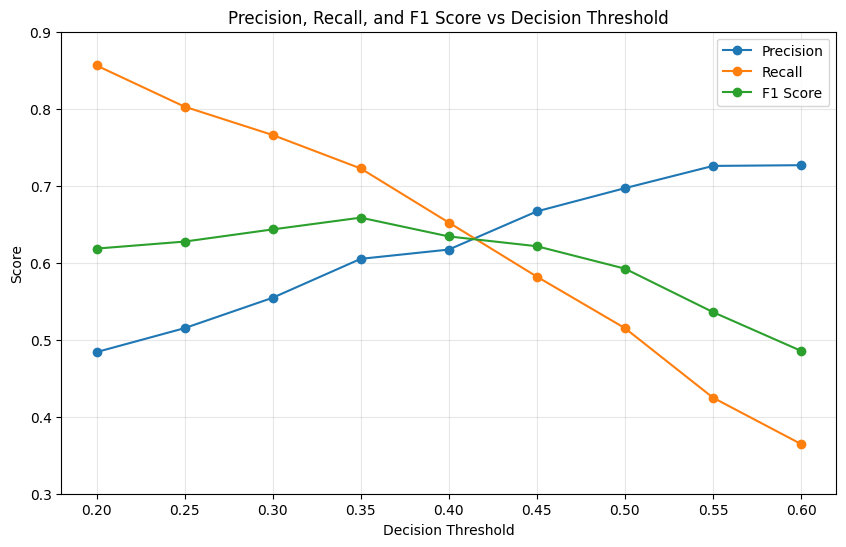

In [ ]:
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision, marker='o', label='Precision')
plt.plot(thresholds, recall, marker='o', label='Recall')
plt.plot(thresholds, f1, marker='o', label='F1 Score')

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs Decision Threshold")

plt.xticks(thresholds)
plt.ylim(0.3, 0.9)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


In [ ]:
evaluate_model("XGboost_tuned",y_valid,valid_pred,valid_prob)


XGboost_tuned
Accuracy : 0.8118899733806566
Precision: 0.6968325791855203
Recall   : 0.5150501672240803
F1 Score : 0.5923076923076923
ROC-AUC  : 0.8570133132987576

Confusion Matrix:
[[761  67]
 [145 154]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       828
           1       0.70      0.52      0.59       299

    accuracy                           0.81      1127
   macro avg       0.77      0.72      0.74      1127
weighted avg       0.80      0.81      0.80      1127



In [ ]:
xgb_final_candidate = XGBClassifier(
    n_estimators=198,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=10,
    gamma=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)


In [ ]:
xgb_final_candidate.fit(X_train_processed,y_train,verbose=False)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [ ]:
final_threshold = 0.35
test_prob = xgb_final_candidate.predict_proba(X_test_processed)[:, 1]

test_pred_threshold = (
    test_prob >= final_threshold
).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, test_pred_threshold))
print("Precision:", precision_score(y_test, test_pred_threshold))
print("Recall   :", recall_score(y_test, test_pred_threshold))
print("F1 Score :", f1_score(y_test, test_pred_threshold))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_threshold))

Accuracy : 0.7778566359119943
Precision: 0.5650319829424307
Recall   : 0.7085561497326203
F1 Score : 0.6287069988137604

Confusion Matrix:
[[831 204]
 [109 265]]


In [ ]:
final_pred=xgb_final_candidate.predict(X_test_processed)
final_pred_prob=xgb_final_candidate.predict_proba(X_test_processed)[:,-1]

In [ ]:
evaluate_model("Final Model",y_test,final_pred,final_pred_prob)


Final Model
Accuracy : 0.8048261178140526
Precision: 0.6677966101694915
Recall   : 0.5267379679144385
F1 Score : 0.5889387144992526
ROC-AUC  : 0.848420264021287

Confusion Matrix:
[[937  98]
 [177 197]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

